# 🥭 Mejora Selectiva de Imágenes — Dataset Mango
### Solo mejora las imágenes que realmente lo necesitan
> Nitidez · Saturación · Brillo  



## 1️⃣ Instalaciones

In [ ]:
!pip install roboflow opencv-python-headless matplotlib tqdm -q

import cv2, os, shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

print("Librerias listas.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 32.1 MB/s eta 0:00:00
Librerias listas.


## 2️⃣ Descarga del Dataset (versión 2)

In [ ]:
from roboflow import Roboflow

rf      = Roboflow(api_key="qsyMWg34JW523ptizLFZ")
project = rf.workspace("herramienta").project("datasetv1-actividad2")
version = project.version(2)
dataset = version.download("folder")          # sintaxis correcta

DATA_DIR  = Path(dataset.location)
SPLITS    = ["train", "valid", "test"]
OUT_DIR   = Path("dataset_mejorado")          # carpeta del nuevo dataset

# Copiar estructura completa al directorio de salida
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
shutil.copytree(DATA_DIR, OUT_DIR)

print(f"Dataset original en : {DATA_DIR}")
print(f"Copia de trabajo en : {OUT_DIR}")

# Verificar estructura
for split in SPLITS:
    p = OUT_DIR / split
    if p.exists():
        clases = [d.name for d in p.iterdir() if d.is_dir()]
        n = sum(len(list(c.glob("*.*"))) for c in p.iterdir() if c.is_dir())
        print(f"  [{split:>5}]  clases={clases}  imagenes={n}")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DatasetV1-Actividad2-2 in folder:: 100%|██████████| 1589/1589 [00:00<00:00, 6273.48it/s]


Dataset original en : /content/DatasetV1-Actividad2-2
Copia de trabajo en : dataset_mejorado
  [train]  clases=['Defectuoso', 'Sanos']  imagenes=1032
  [valid]  clases=['Defectuoso', 'Sanos']  imagenes=239
  [ test]  clases=['Defectuoso', 'Sanos']  imagenes=316


## 3️⃣ Umbrales de Mejora
> Ajusta estos valores según los resultados de tu EDA.  
> Solo se procesa una imagen si **cae por debajo del umbral** correspondiente.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# UMBRALES — modifica estos valores si necesitas ser mas o menos agresivo
# ─────────────────────────────────────────────────────────────────────────────

UMBRAL_NITIDEZ    = 100    # Laplacian variance. Tu clase Sanos tenia media 87.4
UMBRAL_SATURACION = 60     # Valor HSV canal S. Bajo = imagen apagada/gris
UMBRAL_BRILLO_MIN = 50     # Valor HSV canal V. Muy oscura si esta por debajo
UMBRAL_BRILLO_MAX = 200    # Muy brillante / sobreexpuesta si esta por encima

# ─────────────────────────────────────────────────────────────────────────────
# INTENSIDAD de la mejora (0.0 = sin efecto, 1.0 = maximo)
# ─────────────────────────────────────────────────────────────────────────────

INTENSIDAD_NITIDEZ    = 0.6   # fuerza del unsharp masking
INTENSIDAD_SATURACION = 0.4   # cuanto aumentar la saturacion
INTENSIDAD_BRILLO     = 0.35  # cuanto corregir el brillo con CLAHE

print("Umbrales configurados:")
print(f"  Nitidez    < {UMBRAL_NITIDEZ}   → se aplica Unsharp Masking")
print(f"  Saturacion < {UMBRAL_SATURACION}    → se aumenta saturacion HSV")
print(f"  Brillo     < {UMBRAL_BRILLO_MIN} o > {UMBRAL_BRILLO_MAX}  → se aplica CLAHE")


Umbrales configurados:
  Nitidez    < 100   → se aplica Unsharp Masking
  Saturacion < 60    → se aumenta saturacion HSV
  Brillo     < 50 o > 200  → se aplica CLAHE


## 4️⃣ Funciones de Diagnóstico y Mejora

In [ ]:
# ─── DIAGNÓSTICO ──────────────────────────────────────────────────────────────
def diagnosticar(img_bgr):
    """Devuelve metricas de calidad de una imagen BGR."""
    hsv        = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    gray       = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    nitidez    = cv2.Laplacian(gray, cv2.CV_64F).var()
    brillo     = float(hsv[:,:,2].mean())
    saturacion = float(hsv[:,:,1].mean())
    return {
        "nitidez":    round(nitidez, 2),
        "brillo":     round(brillo, 2),
        "saturacion": round(saturacion, 2),
    }

def necesita_mejora(metricas):
    """Devuelve lista de problemas detectados."""
    problemas = []
    if metricas["nitidez"]    < UMBRAL_NITIDEZ:
        problemas.append("nitidez")
    if metricas["saturacion"] < UMBRAL_SATURACION:
        problemas.append("saturacion")
    if metricas["brillo"]     < UMBRAL_BRILLO_MIN:
        problemas.append("brillo_bajo")
    if metricas["brillo"]     > UMBRAL_BRILLO_MAX:
        problemas.append("brillo_alto")
    return problemas

# ─── MEJORAS ──────────────────────────────────────────────────────────────────
def mejorar_nitidez(img_bgr, intensidad=INTENSIDAD_NITIDEZ):
    """
    Unsharp Masking: realza bordes sin distorsionar color.
    Cuanto mayor sea 'intensidad', mas agresivo el realce.
    """
    sigma   = 2.0
    blurred = cv2.GaussianBlur(img_bgr, (0, 0), sigma)
    alpha   = 1.0 + intensidad      # peso original
    beta    = -intensidad           # peso blur (negativo = resta la version borrosa)
    sharp   = cv2.addWeighted(img_bgr, alpha, blurred, beta, 0)
    return np.clip(sharp, 0, 255).astype(np.uint8)

def mejorar_saturacion(img_bgr, intensidad=INTENSIDAD_SATURACION):
    """
    Incrementa saturacion en espacio HSV.
    No afecta tono ni brillo, solo la viveza del color.
    """
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[:,:,1] = np.clip(hsv[:,:,1] * (1.0 + intensidad), 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

def mejorar_brillo(img_bgr, intensidad=INTENSIDAD_BRILLO):
    """
    CLAHE (ecualización adaptativa de histograma).
    Corrige tanto subexposicion como sobreexposicion de forma local.
    Clip limit controla cuanto realce se aplica.
    """
    lab   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    clip  = 1.0 + intensidad * 3.0        # 1.0-4.0 aprox
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def procesar_imagen(img_bgr):
    """
    Pipeline completo: diagnostica y aplica SOLO las mejoras necesarias.
    Devuelve (imagen_mejorada, lista_de_problemas_encontrados).
    """
    metricas  = diagnosticar(img_bgr)
    problemas = necesita_mejora(metricas)
    img_out   = img_bgr.copy()

    if "nitidez" in problemas:
        img_out = mejorar_nitidez(img_out)

    if "saturacion" in problemas:
        img_out = mejorar_saturacion(img_out)

    if "brillo_bajo" in problemas or "brillo_alto" in problemas:
        img_out = mejorar_brillo(img_out)

    return img_out, problemas, metricas

print("Funciones de mejora definidas correctamente.")


Funciones de mejora definidas correctamente.


## 5️⃣ Preview Visual — Antes y Después (muestra aleatoria)

Total imagenes escaneadas   : 1587
Imagenes que necesitan mejora: 732


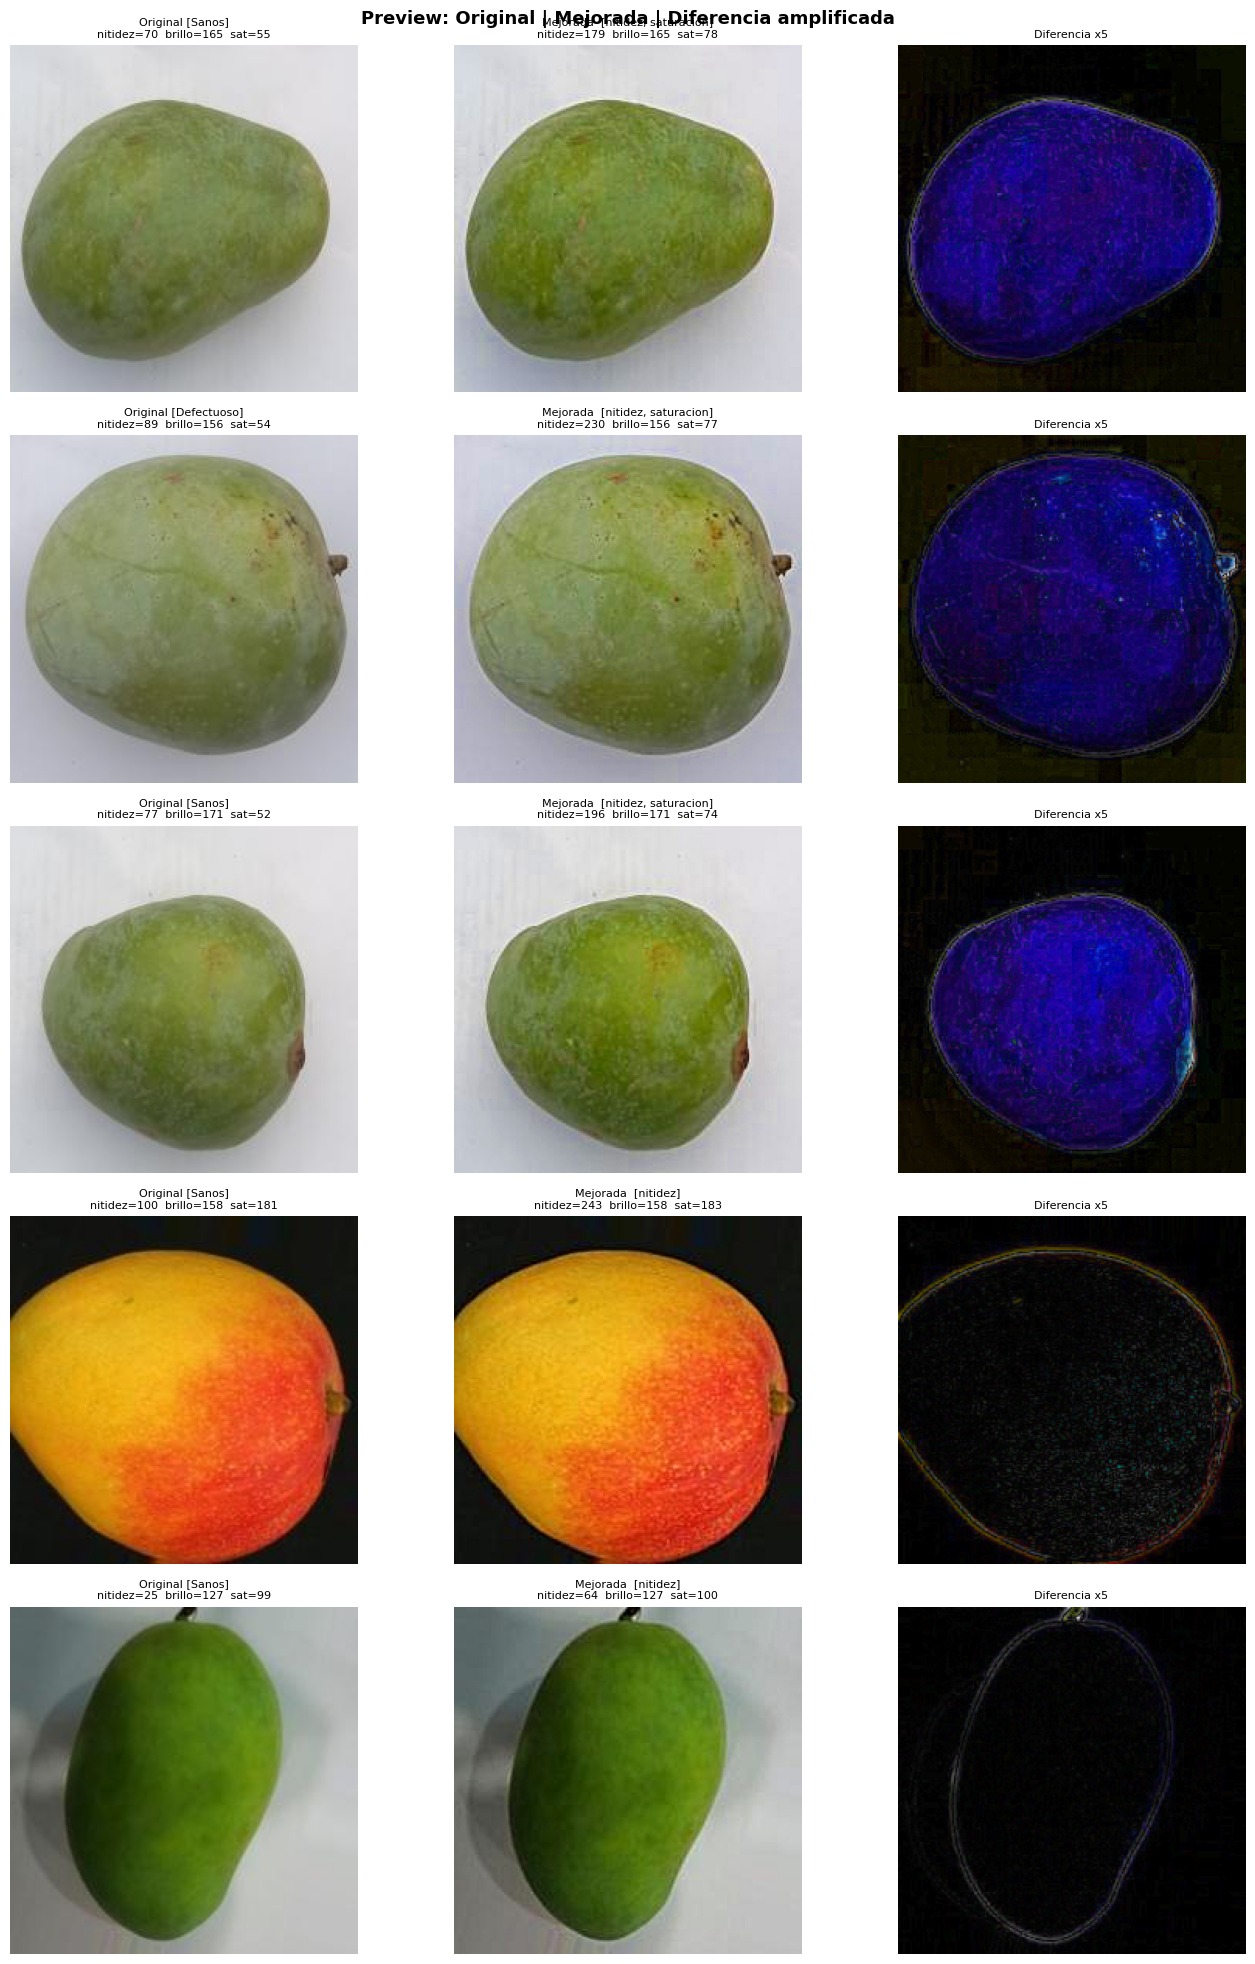


Si el preview se ve bien, ejecuta la siguiente celda para procesar todo el dataset.
Si la mejora es muy agresiva, sube los umbrales o baja las intensidades en la celda 3.


In [ ]:
import random

# Recolectar todas las rutas del directorio ORIGINAL (no el mejorado aun)
all_paths = []
for split in SPLITS:
    for cls_dir in (OUT_DIR / split).iterdir():
        if cls_dir.is_dir():
            all_paths += [(str(p), split, cls_dir.name)
                          for p in cls_dir.glob("*.*")
                          if p.suffix.lower() in {".jpg",".jpeg",".png"}]

# Filtrar solo las que necesitan mejora
candidatas = []
for ruta, split, cls in all_paths:
    img = cv2.imread(ruta)
    if img is None: continue
    m   = diagnosticar(img)
    pb  = necesita_mejora(m)
    if pb:
        candidatas.append((ruta, split, cls, pb, m))

print(f"Total imagenes escaneadas   : {len(all_paths)}")
print(f"Imagenes que necesitan mejora: {len(candidatas)}")

if not candidatas:
    print("\nTodas las imagenes ya estan dentro de los umbrales — no se necesita mejora.")
else:
    # Mostrar muestra de hasta 5 casos
    muestra = random.sample(candidatas, min(5, len(candidatas)))

    fig, axes = plt.subplots(len(muestra), 3, figsize=(14, 4 * len(muestra)))
    fig.suptitle("Preview: Original | Mejorada | Diferencia amplificada",
                 fontsize=13, fontweight="bold")
    if len(muestra) == 1:
        axes = axes.reshape(1, -1)

    for i, (ruta, split, cls, pb, met) in enumerate(muestra):
        img_orig = cv2.imread(ruta)
        img_mej, _, _ = procesar_imagen(img_orig)

        orig_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
        mej_rgb  = cv2.cvtColor(img_mej,  cv2.COLOR_BGR2RGB)

        # Diferencia amplificada x5 para verla claramente
        diff = np.clip(np.abs(mej_rgb.astype(int) - orig_rgb.astype(int)) * 5, 0, 255).astype(np.uint8)

        m_mej = diagnosticar(img_mej)

        axes[i][0].imshow(orig_rgb)
        axes[i][0].set_title(f"Original [{cls}]\n"
                              f"nitidez={met['nitidez']:.0f}  "
                              f"brillo={met['brillo']:.0f}  "
                              f"sat={met['saturacion']:.0f}",
                              fontsize=8)
        axes[i][0].axis("off")

        axes[i][1].imshow(mej_rgb)
        axes[i][1].set_title(f"Mejorada  [{', '.join(pb)}]\n"
                              f"nitidez={m_mej['nitidez']:.0f}  "
                              f"brillo={m_mej['brillo']:.0f}  "
                              f"sat={m_mej['saturacion']:.0f}",
                              fontsize=8)
        axes[i][1].axis("off")

        axes[i][2].imshow(diff)
        axes[i][2].set_title("Diferencia x5", fontsize=8)
        axes[i][2].axis("off")

    plt.tight_layout()
    plt.show()

    print("\nSi el preview se ve bien, ejecuta la siguiente celda para procesar todo el dataset.")
    print("Si la mejora es muy agresiva, sube los umbrales o baja las intensidades en la celda 3.")


## 6️⃣ Procesar Todo el Dataset
> Solo se reescriben las imágenes que necesitan mejora.  
> Las imágenes OK se copian sin cambios.


In [ ]:
# ─── PROCESAMIENTO COMPLETO ───────────────────────────────────────────────────
log = []   # registro de cada imagen procesada

total_imgs      = 0
total_mejoradas = 0
total_ok        = 0
conteo_problemas = {"nitidez": 0, "saturacion": 0, "brillo_bajo": 0, "brillo_alto": 0}

print("Procesando dataset...\n")

for split in SPLITS:
    split_path = OUT_DIR / split
    if not split_path.exists():
        continue

    for cls_dir in sorted(split_path.iterdir()):
        if not cls_dir.is_dir():
            continue

        img_paths = [p for p in cls_dir.glob("*.*")
                     if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp"}]

        for img_path in tqdm(img_paths, desc=f"{split}/{cls_dir.name}", leave=False):
            img = cv2.imread(str(img_path))
            if img is None:
                continue

            total_imgs += 1
            met_orig  = diagnosticar(img)
            img_mej, problemas, _ = procesar_imagen(img)
            met_mej   = diagnosticar(img_mej)

            if problemas:
                # Sobreescribir en la copia de trabajo (OUT_DIR)
                cv2.imwrite(str(img_path), img_mej,
                            [cv2.IMWRITE_JPEG_QUALITY, 95])
                total_mejoradas += 1
                for p in problemas:
                    conteo_problemas[p] += 1
            else:
                total_ok += 1

            log.append({
                "split":           split,
                "clase":           cls_dir.name,
                "archivo":         img_path.name,
                "mejorada":        len(problemas) > 0,
                "problemas":       ", ".join(problemas) if problemas else "ninguno",
                "nitidez_antes":   met_orig["nitidez"],
                "nitidez_despues": met_mej["nitidez"],
                "brillo_antes":    met_orig["brillo"],
                "brillo_despues":  met_mej["brillo"],
                "sat_antes":       met_orig["saturacion"],
                "sat_despues":     met_mej["saturacion"],
            })

# ─── RESUMEN ──────────────────────────────────────────────────────────────────
print("=" * 60)
print("  RESUMEN DEL PROCESAMIENTO")
print("=" * 60)
print(f"  Total imagenes escaneadas : {total_imgs}")
print(f"  Imagenes mejoradas        : {total_mejoradas}  ({total_mejoradas/total_imgs*100:.1f}%)")
print(f"  Imagenes sin cambios (OK) : {total_ok}  ({total_ok/total_imgs*100:.1f}%)")
print()
print("  Desglose de mejoras aplicadas:")
for k, v in conteo_problemas.items():
    if v > 0:
        print(f"    {k:<20}: {v} imagenes")
print()
print(f"  Dataset mejorado guardado en: {OUT_DIR.resolve()}")


Procesando dataset...



train/Defectuoso:   0%|          | 0/512 [00:00<?, ?it/s]

train/Sanos:   0%|          | 0/520 [00:00<?, ?it/s]

valid/Defectuoso:   0%|          | 0/119 [00:00<?, ?it/s]

valid/Sanos:   0%|          | 0/120 [00:00<?, ?it/s]

test/Defectuoso:   0%|          | 0/163 [00:00<?, ?it/s]

test/Sanos:   0%|          | 0/153 [00:00<?, ?it/s]

  RESUMEN DEL PROCESAMIENTO
  Total imagenes escaneadas : 1587
  Imagenes mejoradas        : 732  (46.1%)
  Imagenes sin cambios (OK) : 855  (53.9%)

  Desglose de mejoras aplicadas:
    nitidez             : 684 imagenes
    saturacion          : 316 imagenes
    brillo_bajo         : 7 imagenes
    brillo_alto         : 56 imagenes

  Dataset mejorado guardado en: /content/dataset_mejorado


## 7️⃣ Reporte Estadístico — Antes vs Después

Comparacion de metricas (solo imagenes que fueron mejoradas):

  Nitidez       antes=73.8  despues=206.8  delta=+133.0
  Brillo        antes=162.4  despues=162.3  delta=-0.1
  Saturacion    antes=75.5  despues=83.8  delta=+8.4

Desglose por clase:
mejorada    False  True 
clase                   
Defectuoso    643    151
Sanos         212    581


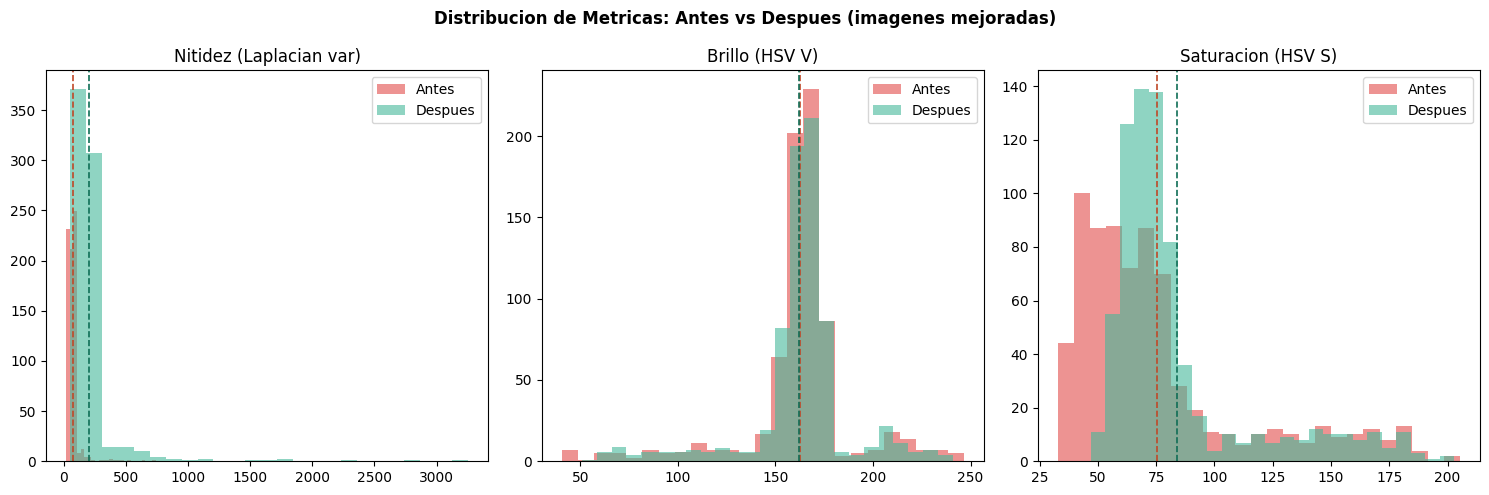

In [ ]:
import pandas as pd

df_log = pd.DataFrame(log)
df_mej = df_log[df_log["mejorada"] == True]

if df_mej.empty:
    print("No se realizaron mejoras — todas las imagenes ya estaban dentro del umbral.")
else:
    print("Comparacion de metricas (solo imagenes que fueron mejoradas):\n")

    for metric, label in [("nitidez","Nitidez"), ("brillo","Brillo"), ("sat","Saturacion")]:
        col_a = f"{metric}_antes"
        col_d = f"{metric}_despues"
        if col_a not in df_mej.columns:
            continue
        delta = df_mej[col_d].mean() - df_mej[col_a].mean()
        signo = "+" if delta >= 0 else ""
        print(f"  {label:<12}  antes={df_mej[col_a].mean():.1f}  "
              f"despues={df_mej[col_d].mean():.1f}  "
              f"delta={signo}{delta:.1f}")

    print()
    print("Desglose por clase:")
    print(df_log.groupby("clase")["mejorada"].value_counts().unstack(fill_value=0).to_string())

    # ── Grafico de distribución de nitidez antes vs después ───────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Distribucion de Metricas: Antes vs Despues (imagenes mejoradas)",
                 fontsize=12, fontweight="bold")

    metrics_cfg = [
        ("nitidez_antes",   "nitidez_despues",   "Nitidez (Laplacian var)", axes[0]),
        ("brillo_antes",    "brillo_despues",     "Brillo (HSV V)",          axes[1]),
        ("sat_antes",       "sat_despues",        "Saturacion (HSV S)",      axes[2]),
    ]

    for col_a, col_d, title, ax in metrics_cfg:
        ax.hist(df_mej[col_a], bins=25, alpha=0.6, color="#E24B4A", label="Antes")
        ax.hist(df_mej[col_d], bins=25, alpha=0.6, color="#44B89A", label="Despues")
        ax.axvline(df_mej[col_a].mean(), color="#C04828", linestyle="--", linewidth=1.2)
        ax.axvline(df_mej[col_d].mean(), color="#0F6E56", linestyle="--", linewidth=1.2)
        ax.set_title(title)
        ax.legend()

    plt.tight_layout()
    plt.show()


## 8️⃣ Verificación Final — ¿Quedan imágenes problemáticas?

In [ ]:
# Escanear el dataset mejorado para ver cuántas siguen bajo umbral
residuales = []
for split in SPLITS:
    for cls_dir in (OUT_DIR / split).iterdir():
        if not cls_dir.is_dir(): continue
        for p in cls_dir.glob("*.*"):
            if p.suffix.lower() not in {".jpg",".jpeg",".png"}: continue
            img = cv2.imread(str(p))
            if img is None: continue
            m  = diagnosticar(img)
            pb = necesita_mejora(m)
            if pb:
                residuales.append({"ruta": str(p), "clase": cls_dir.name,
                                   "split": split, "problemas": pb, **m})

print(f"Imagenes que AUN estan bajo umbral tras la mejora: {len(residuales)}")

if residuales:
    print()
    print("Esto es normal si:")
    print("  a) La imagen estaba muy muy por debajo del umbral (caso extremo)")
    print("  b) El umbral es muy estricto para el contenido fotografico real")
    print()
    print("Opciones:")
    print("  1. Sube INTENSIDAD_NITIDEZ (max recomendado: 1.0) y vuelve a ejecutar")
    print("  2. Baja UMBRAL_NITIDEZ a un valor mas razonable para tu dataset")
    print("  3. Eliminar manualmente las imagenes con nitidez < 50 (casos extremos)")
    print()
    df_res = pd.DataFrame(residuales)
    print("Distribucion de residuales por clase:")
    print(df_res.groupby("clase")["nitidez"].describe().round(1).to_string())
else:
    print("Todas las imagenes estan ahora dentro de los umbrales.")


Imagenes que AUN estan bajo umbral tras la mejora: 250

Esto es normal si:
  a) La imagen estaba muy muy por debajo del umbral (caso extremo)
  b) El umbral es muy estricto para el contenido fotografico real

Opciones:
  1. Sube INTENSIDAD_NITIDEZ (max recomendado: 1.0) y vuelve a ejecutar
  2. Baja UMBRAL_NITIDEZ a un valor mas razonable para tu dataset
  3. Eliminar manualmente las imagenes con nitidez < 50 (casos extremos)

Distribucion de residuales por clase:
            count   mean    std   min   25%   50%    75%     max
clase                                                           
Defectuoso   25.0  165.2  240.7  50.3  79.2  88.0  108.7   994.9
Sanos       225.0  205.3  321.1  47.0  79.6  92.3  188.4  3101.2


## 9️⃣ Exportar Log de Cambios (CSV)

In [ ]:
# Guardar log completo para documentar en la tesis
log_path = "log_mejora_dataset.csv"
df_log.to_csv(log_path, index=False)
print(f"Log guardado en: {log_path}")
print(f"  Total registros: {len(df_log)}")
print(f"  Mejoradas: {df_log['mejorada'].sum()}")
print(f"  Sin cambios: {(~df_log['mejorada']).sum()}")
print()
print("Primeras filas del log:")
print(df_log[df_log["mejorada"]==True].head(5).to_string(index=False))

# Descargar automaticamente en Colab
try:
    from google.colab import files
    files.download(log_path)
    print("\nDescargando log CSV...")
except:
    print(f"\nDescarga manual: busca '{log_path}' en el panel de archivos de Colab.")


Log guardado en: log_mejora_dataset.csv
  Total registros: 1587
  Mejoradas: 732
  Sin cambios: 855

Primeras filas del log:
split      clase                                                    archivo  mejorada           problemas  nitidez_antes  nitidez_despues  brillo_antes  brillo_despues  sat_antes  sat_despues
train Defectuoso defectuoso_413_jpg.rf.951d60f2e1c604b0aa234eeb5d3fb8ae.jpg      True             nitidez          85.43           215.33        160.98          161.13     106.52       107.31
train Defectuoso defectuoso_783_jpg.rf.05633fb0217f7a4574bbdcfa63c448a6.jpg      True nitidez, saturacion          35.21            92.98        168.56          168.66      54.13        76.74
train Defectuoso defectuoso_243_jpg.rf.2f29414cd89babf6c962659b73f12fdb.jpg      True             nitidez          41.43            97.30        107.45          107.63     173.62       170.11
train Defectuoso defectuoso_361_jpg.rf.3ef26f24dfa640777d902afb9baf5d86.jpg      True             nitidez  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Descargando log CSV...


## 🔟 Comprimir y Descargar el Dataset Mejorado

In [ ]:
# ─── OPCION 1: Guardar en Google Drive (MAS CONFIABLE para datasets grandes) ──
from google.colab import drive
drive.mount('/content/drive')

import zipfile, shutil
from pathlib import Path
from tqdm.notebook import tqdm

# Carpeta destino en tu Drive
DRIVE_DEST = Path("/content/drive/MyDrive/dataset_mejorado")

# OPCION A: Copiar carpeta directamente a Drive (sin zip, mas rapido)
print("Copiando dataset a Google Drive...")
if DRIVE_DEST.exists():
    shutil.rmtree(DRIVE_DEST)
shutil.copytree(OUT_DIR, DRIVE_DEST)
print(f"Dataset copiado en Drive: {DRIVE_DEST}")
print(f"Total archivos: {sum(1 for _ in DRIVE_DEST.rglob('*') if _.is_file())}")

print()
print("Para subir a Roboflow desde Drive:")
print("  1. Abre roboflow.com -> tu proyecto -> Upload")
print("  2. Conecta tu Google Drive y selecciona la carpeta dataset_mejorado")
print("  O descarga el ZIP desde Drive a tu PC y subelo manualmente.")


Mounted at /content/drive
Copiando dataset a Google Drive...
Dataset copiado en Drive: /content/drive/MyDrive/dataset_mejorado
Total archivos: 1589

Para subir a Roboflow desde Drive:
  1. Abre roboflow.com -> tu proyecto -> Upload
  2. Conecta tu Google Drive y selecciona la carpeta dataset_mejorado
  O descarga el ZIP desde Drive a tu PC y subelo manualmente.


## 1️⃣1️⃣ (Opcional) Subir el Dataset Mejorado a Roboflow
> Esto crea una **versión 3** del proyecto con las imágenes mejoradas.  
> Solo ejecuta esta celda si quieres tener el dataset limpio directamente en Roboflow.


In [ ]:


PROYECTO_DESTINO = "datasetv1-actividad2-mejorado"   # <-- cambia este nombre
API_KEY          = "qsyMWg34JW523ptizLFZ"

import requests

def subir_imagen_roboflow(api_key, workspace, project, img_path, clase, split):
    import base64
    url = f"https://api.roboflow.com/dataset/{project}/upload"
    params = {
        "api_key": api_key,
        "name":    Path(img_path).name,
        "split":   split,
        "tag":     clase,
    }
    with open(img_path, "rb") as f:
        img_data = base64.b64encode(f.read()).decode("utf-8")

    r = requests.post(url, params=params, json={"image": img_data})
    return r.status_code, r.json().get("success", False)




RECOMENDACION para Roboflow:

La forma MAS SENCILLA de actualizar tu dataset en Roboflow es:

1. Descarga el ZIP generado en la celda anterior (dataset_mejorado.zip)
2. Ve a roboflow.com → tu proyecto → 'Upload'
3. Arrastra el ZIP directamente — Roboflow detecta automaticamente
   la estructura de carpetas (train/valid/test) y las clases.
4. Genera una nueva Version (v3) con las imagenes mejoradas.

Esto conserva todas tus anotaciones y configuraciones previas.



## Resumen de lo que hace este notebook

| Paso | Accion |
|------|--------|
| 1 | Instala librerías |
| 2 | Descarga dataset v2 de Roboflow y crea copia de trabajo |
| 3 | Define umbrales ajustables (nitidez, saturacion, brillo) |
| 4 | Funciones de diagnóstico y mejora selectiva |
| 5 | Preview visual antes/después para validar parámetros |
| 6 | Procesa **solo** las imágenes bajo umbral (las OK no se tocan) |
| 7 | Reporte estadístico con histogramas antes/después |
| 8 | Verifica si quedan imágenes problemáticas |
| 9 | Exporta log CSV para documentar en la tesis |
| 10 | Comprime y descarga el dataset mejorado como ZIP |
| 11 | Instrucciones para subir a Roboflow (opcional) |

**Umbral clave para tu dataset:**  
La clase `Sanos` tenía nitidez media de 87.4 — el umbral de 100 capturará exactamente esas imágenes.  
Las imágenes de `Defectuoso` (media 209.4) no serán tocadas.
